# Módulo 3 — A/B Testing y Multi-Armed Bandits
## Laboratorio: selección de modelos de pronóstico en el panel EVA

**Objetivos**
1. A/B test riguroso entre modelos con test de Diebold-Mariano.
2. Formalizar el selector automático del proyecto como política de bandit.
3. Comparar ε-greedy, UCB1 y Thompson contra el status quo (fijo PM3A) y el oráculo.

**Regret:** $R_T = \sum_t (\ell_{a_t} - \min_a \ell_a)$.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "app.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from core.ml.bandits import (EpsilonGreedy, UCB1, ThompsonGaussian,
                             simulate, diebold_mariano)
from core.ml.io_utils import save_json, save_csv, RESULTS
from config.settings import settings

df = pd.read_csv(settings.DATA_MODEL_PATH / "eva_agricola_valle_modelo_conceptual.csv",
                 low_memory=False)
g = df.groupby(["municipio", "cultivo", "ano"])["produccion_t"].sum().reset_index()
n7 = g.groupby(["municipio", "cultivo"]).ano.nunique()
full = n7[n7 == 7].index
print(f"Series completas: {len(full)}")

Series completas: 794


## 3.1 Matriz de pérdidas: 4 modelos candidatos × rondas (serie, año 2022-2025)

Candidatos baratos y heterogéneos: **PM3A** (status quo), **Naive** (t-1),
**Trend** (OLS lineal), **PM5A** (promedio 5 años).

In [2]:
ARMS = ["PM3A", "Naive", "Trend", "PM5A"]
rows = []
for (mun, cul) in full:
    s = g[(g.municipio == mun) & (g.cultivo == cul)].sort_values("ano")
    p = s.produccion_t.values
    for t in range(3, 7):
        real = p[t]
        if real <= 1e-8:
            continue
        preds = {
            "PM3A": p[t-3:t].mean(),
            "Naive": p[t-1],
            "Trend": np.polyfit(np.arange(t), p[:t], 1)[0] * t + np.polyfit(np.arange(t), p[:t], 1)[1],
            "PM5A": p[max(0, t-5):t].mean(),
        }
        rows.append([mun, cul, 2019 + t, real] +
                    [abs(preds[a] - real) / real * 100 for a in ARMS])
L = pd.DataFrame(rows, columns=["municipio", "cultivo", "ano", "real"] + ARMS)
losses = L[ARMS].values
print(f"Rondas: {len(L)} | APE medio por brazo:\n{L[ARMS].mean().round(2)}")

Rondas: 3170 | APE medio por brazo:
PM3A     61.32
Naive    34.11
Trend    82.11
PM5A     82.36
dtype: float64


## 3.2 A/B test: PM3A vs Trend con Diebold-Mariano
¿Es el status quo significativamente mejor/peor que la tendencia lineal?

In [3]:
dm, p = diebold_mariano(L["PM3A"].values, L["Trend"].values)
print(f"DM = {dm:.3f} | p = {p:.4f}")
print("Interpretacion:",
      "diferencia significativa" if p < 0.05 else "sin diferencia significativa",
      "(alpha=0.05);", "PM3A peor que Trend" if dm > 0 else "PM3A mejor que Trend")
save_json("m3_diebold_mariano.json", {"dm": dm, "p": p})

DM = -2.029 | p = 0.0424
Interpretacion: diferencia significativa (alpha=0.05); PM3A mejor que Trend
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m3_diebold_mariano.json


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m3_diebold_mariano.json')

## 3.3 Torneo de bandits: regret acumulado (10 semillas)

Fijo PM3A (status quo)     regret final: 121,106
Epsilon 0.1                regret final: 50,389
UCB1                       regret final: 54,071
Thompson                   regret final: 70,763


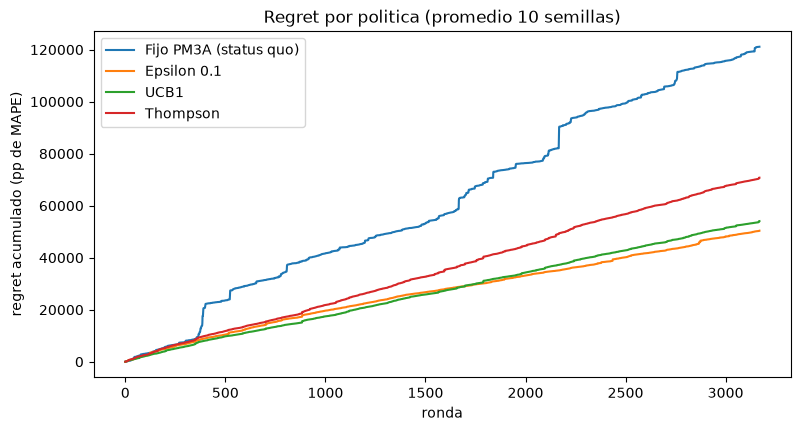

[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m3_regret_final.json


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m3_regret_final.json')

In [4]:
T = len(losses)
policies = {"Fijo PM3A (status quo)": None,
            "Epsilon 0.1": EpsilonGreedy(4, 0.1),
            "UCB1": UCB1(4),
            "Thompson": ThompsonGaussian(4)}
curvas, finales = {}, {}
for nombre, pol in policies.items():
    regs = []
    for seed in range(10):
        rng = np.random.RandomState(seed)
        order = rng.permutation(T)
        if pol is None:
            best = losses.min(axis=1)
            regs.append(np.cumsum(losses[:, 0] - best))
        else:
            fresh = type(pol)(4) if not isinstance(pol, EpsilonGreedy) else EpsilonGreedy(4, 0.1)
            if isinstance(pol, UCB1): fresh = UCB1(4)
            if isinstance(pol, ThompsonGaussian): fresh = ThompsonGaussian(4)
            r, _ = simulate(fresh, losses, order)
            regs.append(r)
    curvas[nombre] = np.mean(regs, axis=0)
    finales[nombre] = curvas[nombre][-1]
    print(f"{nombre:26s} regret final: {finales[nombre]:,.0f}")

plt.figure(figsize=(9, 4.5))
for k, v in curvas.items():
    plt.plot(v, label=k)
plt.xlabel("ronda"); plt.ylabel("regret acumulado (pp de MAPE)")
plt.title("Regret por politica (promedio 10 semillas)"); plt.legend(); plt.show()
save_json("m3_regret_final.json", {k: float(v) for k, v in finales.items()})

## 3.4 ¿Cuánto vale el bandit en la práctica?
Regret final = puntos de MAPE regalados vs oráculo. Compara contra el status quo.

In [5]:
tabla = pd.DataFrame({"regret_final": finales}).round(0)
tabla["vs_status_quo_%"] = ((tabla.regret_final / finales["Fijo PM3A (status quo)"] - 1) * 100).round(1)
print(tabla.to_string())
save_csv("m3_torneo_bandits.csv", tabla)

                        regret_final  vs_status_quo_%
Fijo PM3A (status quo)      121106.0              0.0
Epsilon 0.1                  50389.0            -58.4
UCB1                         54071.0            -55.4
Thompson                     70763.0            -41.6
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m3_torneo_bandits.csv


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m3_torneo_bandits.csv')

## 3.5 Interpretación + ética de la exploración

- Si Thompson/UCB quedan cerca del oráculo y muy por debajo del status quo:
  **explorar paga**. Tu selector actual (ε=0) nunca prueba modelos nuevos.
- En política pública, explorar = arriesgar recomendaciones → eso se discute
  en el Módulo 6 (ética): ε pequeño, exploración acotada a cultivos no críticos,
  y siempre con intervalos de confianza visibles.